In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
def clean_currency(x):
    if isinstance(x, (int, float)):
        return x
    if isinstance(x, str):
        clean_str = x.replace('$', '').replace(',', '')
        try:
            return float(clean_str)
        except ValueError:
            return 0
    return 0

def clean_ram(x):
    if isinstance(x, (int, float)):
        return x
    if isinstance(x, str):
        nums = ''.join(filter(str.isdigit, x))
        return float(nums) if nums else 0
    return 0

def identify_maker(row):
    full_text = (str(row.get('name', '')) + " " + str(row.get('chipset', ''))).upper()
    if 'NVIDIA' in full_text or 'GEFORCE' in full_text:
        return 'NVIDIA'
    elif 'AMD' in full_text or 'RADEON' in full_text:
        return 'AMD'
    return 'Other'


Mean Squared Error của mô hình: 0.4743


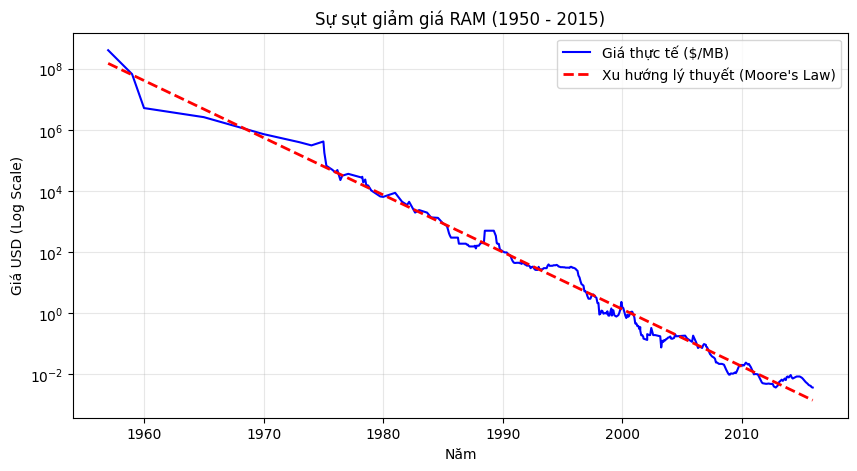

In [8]:
df = pd.read_csv('ram_price.csv')

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(df['date'], df['price'], label='Giá thực tế ($/MB)', color='blue')
        

model = LinearRegression()
X = df[['date']]
y_log = np.log(df['price']) 
model.fit(X, y_log)
trend = np.exp(model.predict(X))
        
ax.plot(df['date'], trend, 'r--', label="Xu hướng lý thuyết (Moore's Law)", linewidth=2)
        
ax.set_title("Sự sụt giảm giá RAM (1950 - 2015)")
ax.set_xlabel("Năm")
ax.set_ylabel("Giá USD (Log Scale)")
ax.legend()
ax.grid(True, alpha=0.3)

mse = np.mean((y_log - model.predict(X)) ** 2)
print(f"Mean Squared Error của mô hình: {mse:.4f}")

Mean Squared Error: 368925.79


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


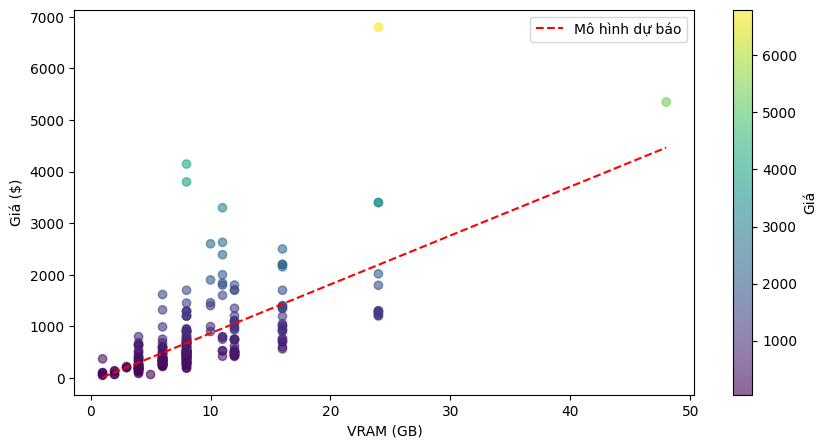

In [ ]:
df = pd.read_csv('gpu_specs_prices.csv', encoding='latin-1')
df['VRAM'] = df['memory'].apply(clean_ram)
df['Price'] = df['price'].apply(clean_currency)
df = df[(df['Price'] > 0) & (df['VRAM'] > 0)]


X = df[['VRAM']]
y = df['Price']
model = LinearRegression()
model.fit(X, y)
price_per_gb = model.coef_[0]


fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(df['VRAM'], df['Price'], c=df['Price'], cmap='viridis', alpha=0.6)


x_range = np.linspace(df['VRAM'].min(), df['VRAM'].max(), 100).reshape(-1, 1)
ax.plot(x_range, model.predict(x_range), 'r--', label='Mô hình dự báo')
        
ax.set_xlabel("VRAM (GB)")
ax.set_ylabel("Giá ($)")
plt.colorbar(sc, label="Giá")
ax.legend()



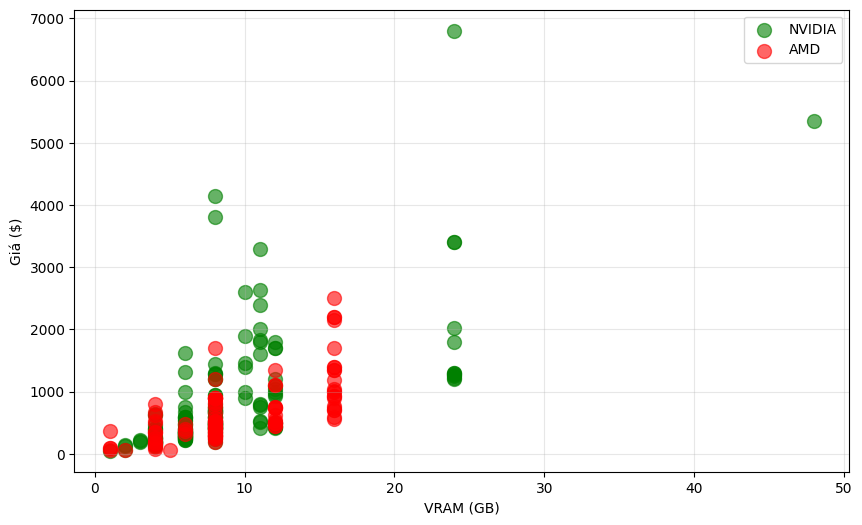

In [6]:
df = pd.read_csv('gpu_specs_prices.csv', encoding='latin-1')
df['VRAM'] = df['memory'].apply(clean_ram)
df['Price'] = df['price'].apply(clean_currency)
df = df[(df['Price'] > 0) & (df['VRAM'] > 0)]
        

df['Brand_Clean'] = df.apply(identify_maker, axis=1)
df = df[df['Brand_Clean'].isin(['NVIDIA', 'AMD'])]


df['Price_Per_GB'] = df['Price'] / df['VRAM']
        

avg_nvidia = df[df['Brand_Clean'] == 'NVIDIA']['Price_Per_GB'].mean()
avg_amd = df[df['Brand_Clean'] == 'AMD']['Price_Per_GB'].mean()



fig, ax = plt.subplots(figsize=(10, 6))
        

for brand, color in [('NVIDIA', 'green'), ('AMD', 'red')]:
    subset = df[df['Brand_Clean'] == brand]
    ax.scatter(subset['VRAM'], subset['Price'], c=color, label=brand, alpha=0.6, s=100)
            
ax.set_xlabel("VRAM (GB)")
ax.set_ylabel("Giá ($)")
ax.legend()
ax.grid(True, alpha=0.3)

c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


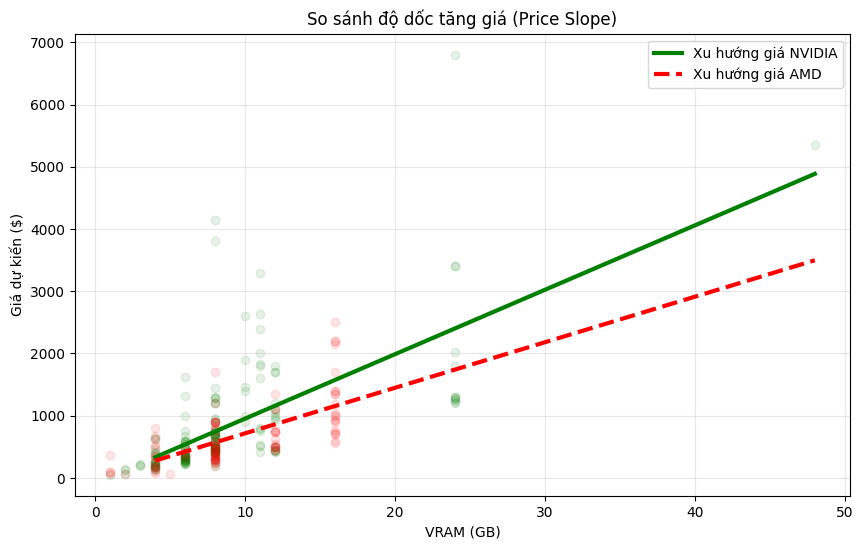

In [7]:

df = pd.read_csv('gpu_specs_prices.csv', encoding='latin-1')
df['VRAM'] = df['memory'].apply(clean_ram)
df['Price'] = df['price'].apply(clean_currency)
df = df[(df['Price'] > 0) & (df['VRAM'] > 0)]
df['Brand_Clean'] = df.apply(identify_maker, axis=1)
        

df_nvidia = df[df['Brand_Clean'] == 'NVIDIA']
df_amd = df[df['Brand_Clean'] == 'AMD']


model_nvidia = LinearRegression()
model_nvidia.fit(df_nvidia[['VRAM']], df_nvidia['Price'])
        
model_amd = LinearRegression()
model_amd.fit(df_amd[['VRAM']], df_amd['Price'])
     


fig, ax = plt.subplots(figsize=(10, 6))
        

x_range = np.linspace(4, 48, 100).reshape(-1, 1)
        

ax.plot(x_range, model_nvidia.predict(x_range), color='green', linewidth=3, label='Xu hướng giá NVIDIA')
ax.scatter(df_nvidia['VRAM'], df_nvidia['Price'], color='green', alpha=0.1)
        

ax.plot(x_range, model_amd.predict(x_range), color='red', linewidth=3, linestyle='--', label='Xu hướng giá AMD')
ax.scatter(df_amd['VRAM'], df_amd['Price'], color='red', alpha=0.1) 
        
ax.set_title("So sánh độ dốc tăng giá (Price Slope)")
ax.set_xlabel("VRAM (GB)")
ax.set_ylabel("Giá dự kiến ($)")
ax.legend()
ax.grid(True, alpha=0.3)